In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams['figure.max_open_warning'] = 0
    
plt.rcParams['mathtext.fontset']  = 'stix'
plt.rcParams['font.family']       = 'STIXGeneral'

plt.rcParams['font.size']         = 14
plt.rcParams['axes.linewidth']    = 1
plt.rcParams['axes.labelsize']    = plt.rcParams['font.size']
plt.rcParams['axes.titlesize']    = 1.5*plt.rcParams['font.size']
plt.rcParams['legend.fontsize']   = plt.rcParams['font.size']
plt.rcParams['xtick.labelsize']   = plt.rcParams['font.size']
plt.rcParams['ytick.labelsize']   = plt.rcParams['font.size']
plt.rcParams['xtick.major.size']  = 3
plt.rcParams['xtick.minor.size']  = 3
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.major.size']  = 3
plt.rcParams['ytick.minor.size']  = 3
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 1

plt.rcParams['legend.frameon']             = False
plt.rcParams['legend.loc']                 = 'center left'
plt.rcParams['contour.negative_linestyle'] = 'solid'

### QC Fits

$$A_{\bar{h}}(\tau)=c_1^A\tanh(c_2^A\tau+c_3^A)+c_4^A$$
$$\phi_{\bar{h}}(\tau)=-c_1^{\phi}\ln\left(\frac{1+c_3^{\phi}\exp(-c_2^{\phi}\tau)+c_4^{\phi}\exp(-2c_2^{\phi}\tau)}{1+c_3^{\phi}+c_4^{\phi}}\right)$$

Amplitudes:
- $c_1^A=A_{22}^{\text{mrg}}\alpha_1\frac{\cosh^2c_3^A}{c_2^A}$
- $c_2^A=\frac{\alpha_2-\alpha_1}{2}$
- $c_3^A$ *free*
- $c_4^A=A_{22}^{\text{mrg}}-c_1^A\tanh(c_3^A)$

Phases:
- $c_1^{\phi}=\frac{(\omega_1-\mathcal{M}_{\text{BH}}\omega_{22}^{\text{mrg}})(1+c_3^{\phi}+c_4^{\phi})}{c_2^{\phi}(c_3^{\phi}+2c_4^{\phi})}$
- $c_2^{\phi}=\alpha_2-\alpha_1$
- $c_3^{\phi}$ *free*
- $c_4^{\phi}$ *free*

In [3]:
A_22_mrg = 0.3932379086373926
alpha_1 = 0.08896
alpha_2 = 0.184953 + 0.08896
omega_1 = 0.373672
omega_2 = 0.3639127188544364 * 0.9516104403

In [4]:
c3Amin = -0.5
c3Amax = -0.1
c3Pmin = 2
c3Pmax = 7
c4Pmin = 0
c4Pmax = 10

In [5]:
def qc_amplitude(c3A, tau):
    c2A = (alpha_2 - alpha_1) / 2
    c1A = A_22_mrg * alpha_1 * np.cosh(c3A)**2 / c2A
    c4A = A_22_mrg - c1A * np.tanh(c3A)
    amp = c1A * np.tanh(c2A * tau + c3A) + c4A
    return amp

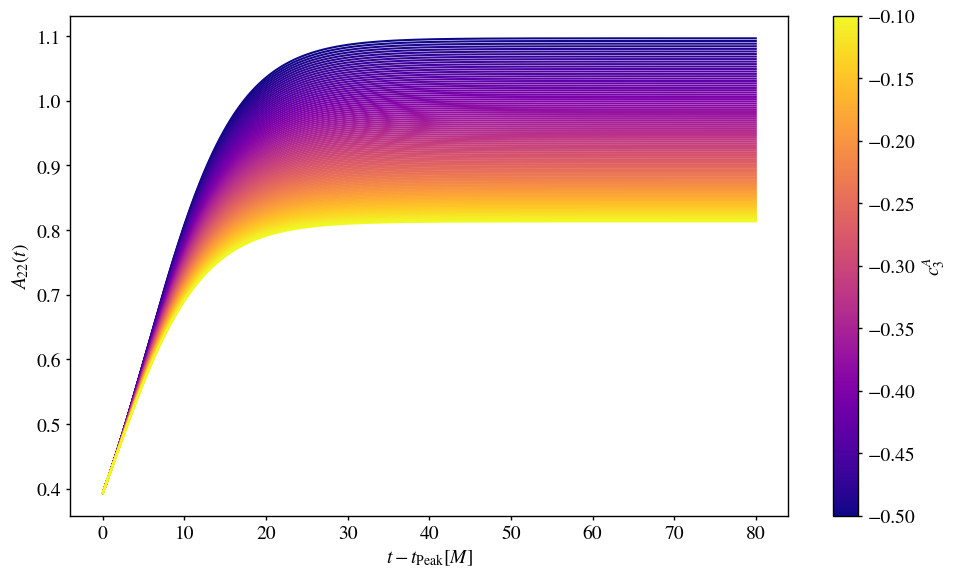

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
tau = np.linspace(0, 80, 1000)
c3Aspace = np.linspace(c3Amin, c3Amax, 100)
cmap_amp = plt.get_cmap('plasma')
norm_amp = plt.Normalize(vmin=c3Aspace.min(), vmax=c3Aspace.max())
for c3A in c3Aspace:
    amp = qc_amplitude(c3A, tau)
    ax.plot(tau, amp, color=cmap_amp(norm_amp(c3A)))
ax.set_xlabel('$t-t_{\\rm Peak} [M]$')
ax.set_ylabel('$A_{22}(t)$')
sm_amp = plt.cm.ScalarMappable(cmap=cmap_amp, norm=norm_amp)
sm_amp.set_array([])
cbar_amp = plt.colorbar(sm_amp, ax=ax)
cbar_amp.set_label('$c_3^A$')
plt.tight_layout()
plt.show()

In [7]:
def qc_phase(c3P, c4P, tau):
    c2P = alpha_2 - alpha_1
    c1P = (omega_1 - A_22_mrg * omega_2) * (1 + c3P + c4P) / (c2P * (c3P + 2 * c4P))
    phi = -c1P * np.log((1 + c3P * np.exp(-c2P * tau) + c4P * np.exp(-2 * c2P * tau)) / (1 + c3P + c4P))
    return phi

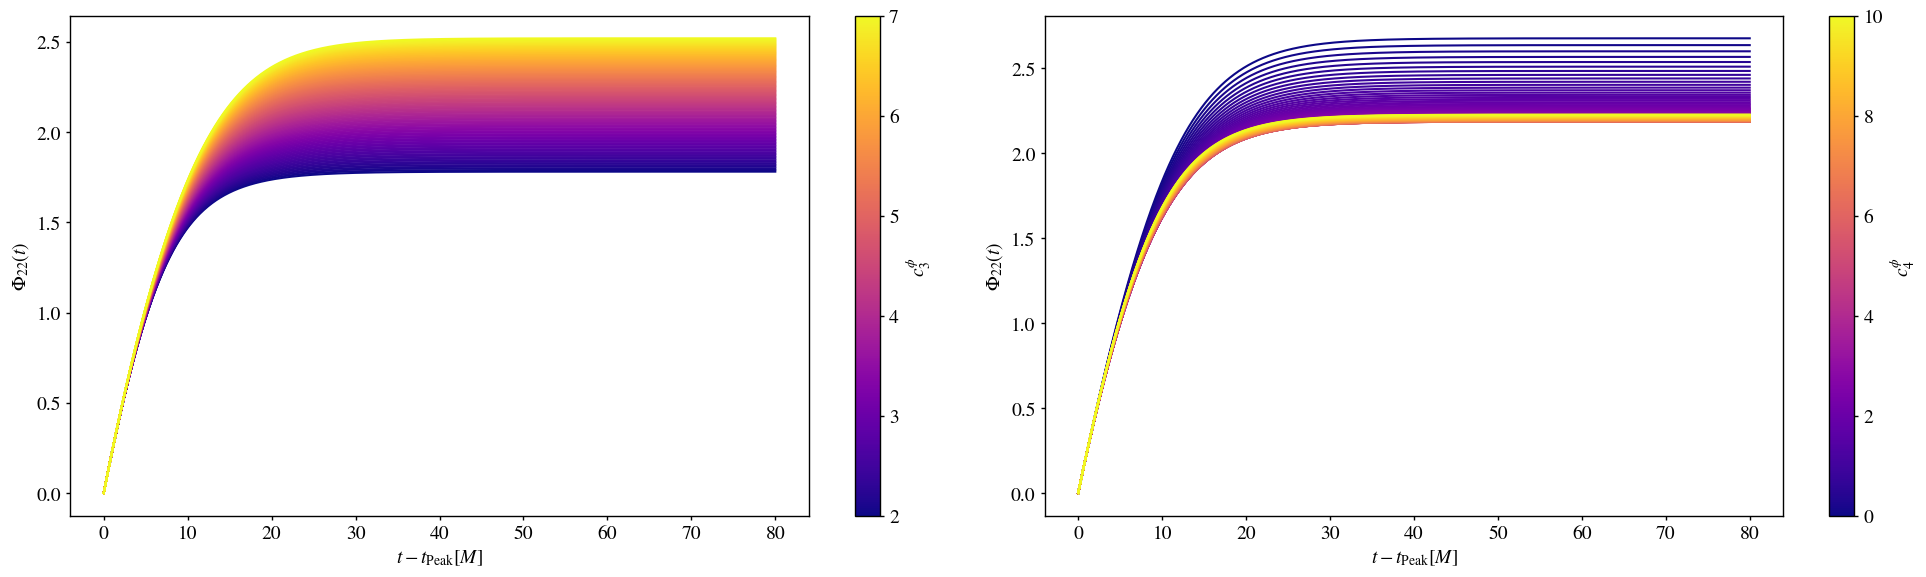

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(20, 6))
tau = np.linspace(0, 80, 1000)
c3Pspace = np.linspace(c3Pmin, c3Pmax, 100)
c4P = (c4Pmin + c4Pmax) / 2
cmap_phi = plt.get_cmap('plasma')
norm_phi = plt.Normalize(vmin=c3Pspace.min(), vmax=c3Pspace.max())
for c3P in c3Pspace:
    phi = qc_phase(c3P, c4P, tau)
    ax[0].plot(tau, phi, color=cmap_phi(norm_phi(c3P)))
ax[0].set_xlabel('$t-t_{\\rm Peak} [M]$')
ax[0].set_ylabel('$\\Phi_{22}(t)$')
sm_phi = plt.cm.ScalarMappable(cmap=cmap_phi, norm=norm_phi)
sm_phi.set_array([])
cbar_phi = plt.colorbar(sm_phi, ax=ax[0])
cbar_phi.set_label('$c_3^{\\phi}$')
c4pspace = np.linspace(c4Pmin, c4Pmax, 100)
c3P = (c3Pmin + c3Pmax) / 2
norm_phi = plt.Normalize(vmin=c4pspace.min(), vmax=c4pspace.max())
for c4P in c4pspace:
    phi = qc_phase(c3P, c4P, tau)
    ax[1].plot(tau, phi, color=cmap_phi(norm_phi(c4P)))
ax[1].set_xlabel('$t-t_{\\rm Peak} [M]$')
ax[1].set_ylabel('$\\Phi_{22}(t)$')
sm_phi = plt.cm.ScalarMappable(cmap=cmap_phi, norm=norm_phi)
sm_phi.set_array([])
cbar_phi = plt.colorbar(sm_phi, ax=ax[1])
cbar_phi.set_label('$c_4^{\\phi}$')
plt.tight_layout()
plt.show()

### NC Fits

$$A_{\bar{h}}(\tau)=\left(\frac{c_1^A}{1+\exp(-c_2^A\tau+c_3^A)}+c_4^A\right)^{\frac{1}{c_5^A}}$$
$$\phi_{\bar{h}}(\tau)= -c_1^{\phi}\ln\left(\frac{1+c_3^{\phi}\exp(-c_2^{\phi}\tau)+c_4^{\phi}\exp(-2c_2^{\phi}\tau)}{1+c_3^{\phi}+c_4^{\phi}}\right)$$

Amplitudes:
- $c_1^A=\frac{c_5^A\alpha_1}{c_2^A}(A_{22}^{\text{mrg}})^{c_5^A}\exp(-c_3^A)(1+\exp(c_3^A))^2$
- $c_2^A$ *free*
- $c_3^A$ *free*
- $c_4^A=(A_{22}^{\text{mrg}})^{c_5^A}-\frac{c_1^A}{1+\exp(c_3^A)}$
- $c_5^A=-\frac{\ddot{A}_{22}^{\text{mrg}}}{A_{22}^{\text{mrg}}\alpha_1^2}+\frac{c_2^A}{\alpha_1}\frac{\exp(c_3^A)-1}{\exp(c_3^A)+1}$

Phases:
- $c_1^{\phi}=\frac{1+c_3^{\phi}+c_4^{\phi}}{c_2^{\phi}(c_3^{\phi}+2c_4^{\phi})}\Delta\omega$ 
- $c_2^{\phi}$ *free*
- $c_3^{\phi}$ *free*
- $c_4^{\phi}$ *free*

In [9]:
A_22_mrg_ddot = -0.3639127188544364
delta_omega = omega_1 - omega_2

In [10]:
c2Amin = -5
c2Amax = 4.9
c3Amin = -4.5
c3Amax = 0.9
c2Pmin = 0.1
c2Pmax = 10
c3Pmin = 0.1
c3Pmax = 10
c4Pmin = 0.1
c4Pmax = 10

In [11]:
def nc_amplitude(c2A, c3A, tau):
    c5A = -A_22_mrg_ddot / (A_22_mrg * alpha_1**2) + c2A / alpha_1 * (np.exp(c3A) - 1) / (np.exp(c3A) + 1)
    c1A = c5A * alpha_1 / c2A * A_22_mrg**c5A * np.exp(-c3A) * (1 + np.exp(c3A))**2
    c4A = A_22_mrg**c5A - c1A / (1 + np.exp(c3A))
    amp = (c1A / (1 + np.exp(-c2A * tau + c3A)) + c4A)**(1 / c5A)
    return amp 

/tmp/ipykernel_40997/3753674844.py:3: RuntimeWarning: divide by zero encountered in scalar divide
  c1A = c5A * alpha_1 / c2A * A_22_mrg**c5A * np.exp(-c3A) * (1 + np.exp(c3A))**2
/tmp/ipykernel_40997/3753674844.py:5: RuntimeWarning: invalid value encountered in add
  amp = (c1A / (1 + np.exp(-c2A * tau + c3A)) + c4A)**(1 / c5A)


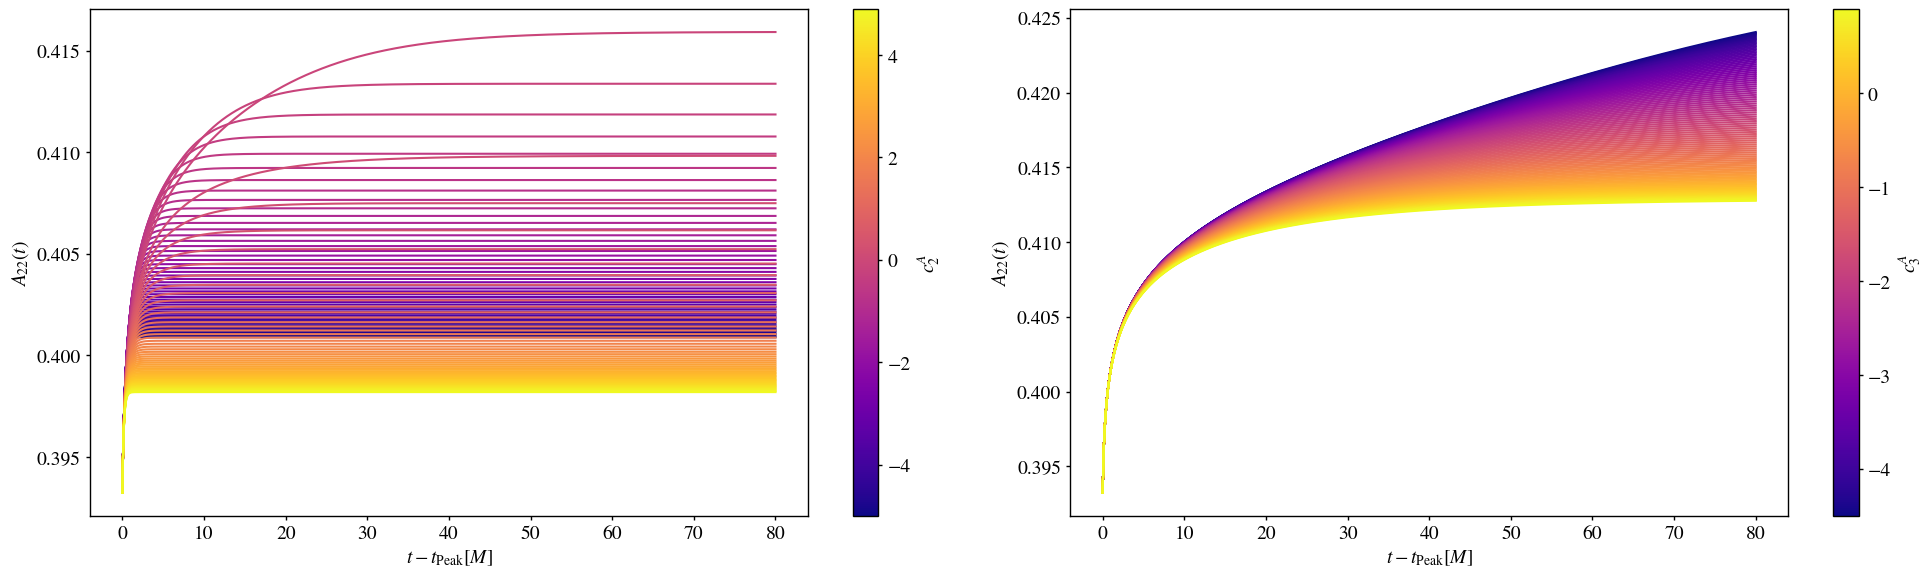

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(20, 6))
tau = np.linspace(0, 80, 1000)
c2Aspace = np.linspace(c2Amin, c2Amax, 100) 
c3A = (c3Amin + c3Amax) / 2
cmap_amp = plt.get_cmap('plasma')
norm_amp = plt.Normalize(vmin=c2Aspace.min(), vmax=c2Aspace.max())
for c2A in c2Aspace:
    amp = nc_amplitude(c2A, c3A, tau)
    ax[0].plot(tau, amp, color=cmap_amp(norm_amp(c2A)))
ax[0].set_xlabel('$t-t_{\\rm Peak} [M]$')
ax[0].set_ylabel('$A_{22}(t)$')
sm_amp = plt.cm.ScalarMappable(cmap=cmap_amp, norm=norm_amp)
sm_amp.set_array([])
cbar_amp = plt.colorbar(sm_amp, ax=ax[0])
cbar_amp.set_label('$c_2^A$')
c3Aspace = np.linspace(c3Amin, c3Amax, 100)
c2A = (c2Amin + c2Amax) / 2
norm_amp = plt.Normalize(vmin=c3Aspace.min(), vmax=c3Aspace.max())
for c3A in c3Aspace:
    amp = nc_amplitude(c2A, c3A, tau)
    ax[1].plot(tau, amp, color=cmap_amp(norm_amp(c3A)))
ax[1].set_xlabel('$t-t_{\\rm Peak} [M]$')
ax[1].set_ylabel('$A_{22}(t)$')
sm_amp = plt.cm.ScalarMappable(cmap=cmap_amp, norm=norm_amp)
sm_amp.set_array([])
cbar_amp = plt.colorbar(sm_amp, ax=ax[1])
cbar_amp.set_label('$c_3^A$')
plt.tight_layout()
plt.show()

In [13]:
def nc_phase(c2P, c3P, c4P, tau):
    c1P = (1 + c3P + c4P) / (c2P * (c3P + 2 * c4P)) * delta_omega
    phi = -c1P * np.log((1 + c3P * np.exp(-c2P * tau) + c4P * np.exp(-2 * c2P * tau)) / (1 + c3P + c4P))
    return phi

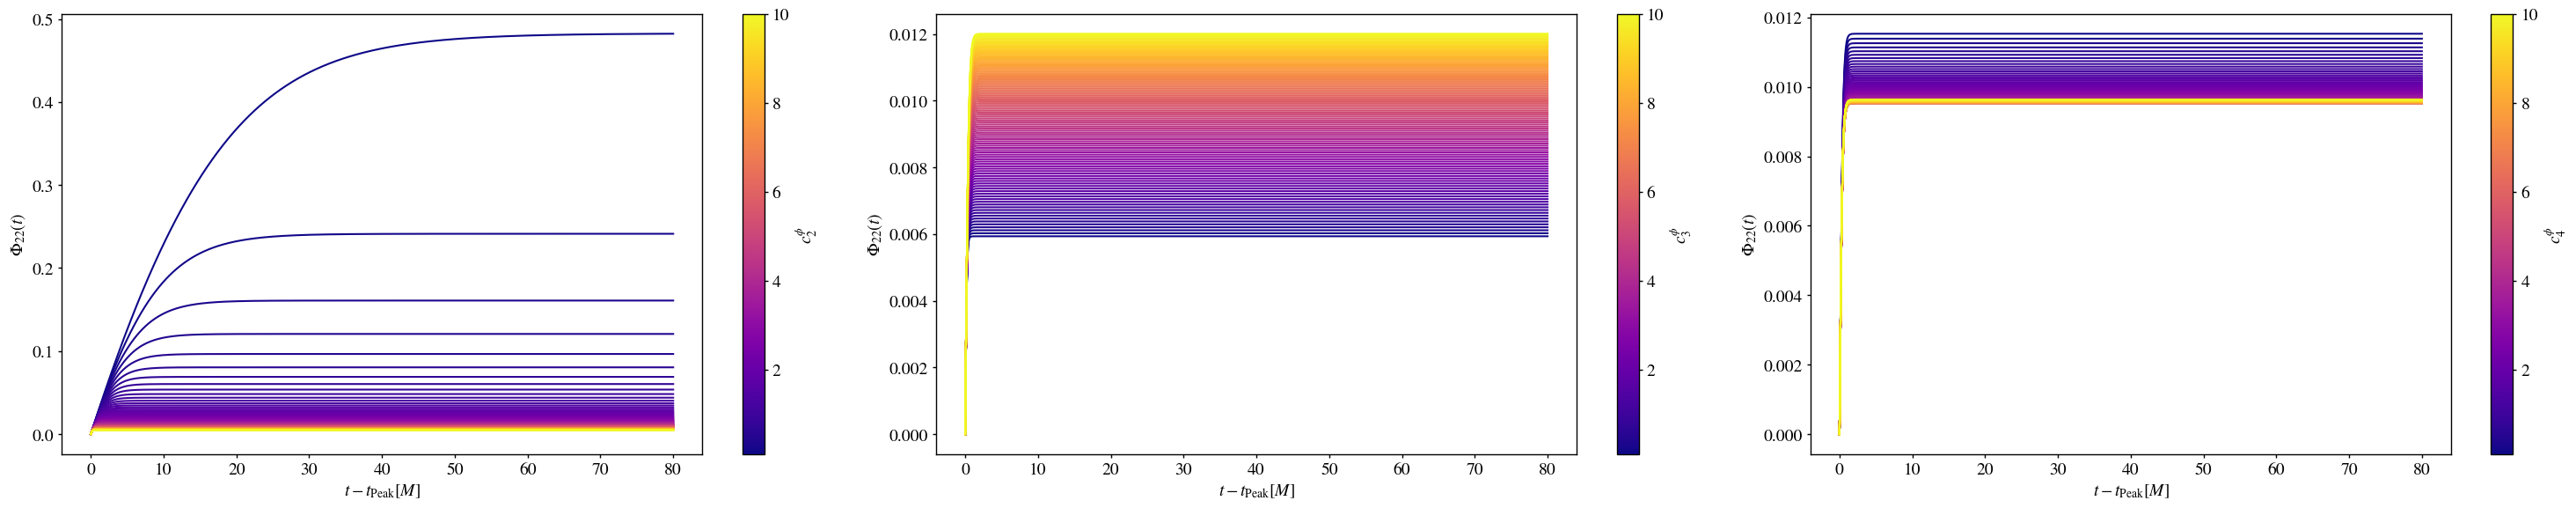

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(30, 6))
tau = np.linspace(0, 80, 1000)
c2Pspace = np.linspace(c2Pmin, c2Pmax, 100)
c3P = (c3Pmin + c3Pmax) / 2
c4P = (c4Pmin + c4Pmax) / 2
cmap_phi = plt.get_cmap('plasma')
norm_phi = plt.Normalize(vmin=c2Pspace.min(), vmax=c2Pspace.max())
for c2P in c2Pspace:
    phi = nc_phase(c2P, c3P, c4P, tau)
    ax[0].plot(tau, phi, color=cmap_phi(norm_phi(c2P)))
ax[0].set_xlabel('$t-t_{\\rm Peak} [M]$')
ax[0].set_ylabel('$\\Phi_{22}(t)$')
sm_phi = plt.cm.ScalarMappable(cmap=cmap_phi, norm=norm_phi)
sm_phi.set_array([])
cbar_phi = plt.colorbar(sm_phi, ax=ax[0])
cbar_phi.set_label('$c_2^{\\phi}$')
c3Pspace = np.linspace(c3Pmin, c3Pmax, 100)
c2P = (c2Pmin + c2Pmax) / 2
c4P = (c4Pmin + c4Pmax) / 2
norm_phi = plt.Normalize(vmin=c3Pspace.min(), vmax=c3Pspace.max())
for c3P in c3Pspace:
    phi = nc_phase(c2P, c3P, c4P, tau)
    ax[1].plot(tau, phi, color=cmap_phi(norm_phi(c3P)))
ax[1].set_xlabel('$t-t_{\\rm Peak} [M]$')
ax[1].set_ylabel('$\\Phi_{22}(t)$')
sm_phi = plt.cm.ScalarMappable(cmap=cmap_phi, norm=norm_phi)
sm_phi.set_array([])
cbar_phi = plt.colorbar(sm_phi, ax=ax[1])
cbar_phi.set_label('$c_3^{\\phi}$')
c4pspace = np.linspace(c4Pmin, c4Pmax, 100)
c2P = (c2Pmin + c2Pmax) / 2
c3P = (c3Pmin + c3Pmax) / 2
norm_phi = plt.Normalize(vmin=c4pspace.min(), vmax=c4pspace.max())
for c4P in c4pspace:
    phi = nc_phase(c2P, c3P, c4P, tau)
    ax[2].plot(tau, phi, color=cmap_phi(norm_phi(c4P)))
ax[2].set_xlabel('$t-t_{\\rm Peak} [M]$')
ax[2].set_ylabel('$\\Phi_{22}(t)$')
sm_phi = plt.cm.ScalarMappable(cmap=cmap_phi, norm=norm_phi)
sm_phi.set_array([])
cbar_phi = plt.colorbar(sm_phi, ax=ax[2])
cbar_phi.set_label('$c_4^{\\phi}$')
plt.tight_layout()
plt.show()

### Waveforms

$$h(t)=A_{\bar{h}}(\tau)\exp(i\phi_{\bar{h}}(\tau))$$
$$f(t)=\dot{\phi}_{\bar{h}}(\tau)$$

In [15]:
def instantaneous_frequency(phi, tau):
    dphi = np.gradient(phi, tau)
    return dphi

In [24]:
def plot_all_variations(
    c2Amin, c2Amax,
    c3Amin, c3Amax,
    c2Pmin, c2Pmax,
    c3Pmin, c3Pmax,
    c4Pmin, c4Pmax,
    nspace=100,
    tau_end=80.0,
    tau_npts=1000,
    cmap_name='plasma',
    figsize=(18,6),
    show=True,
):
    
    tau = np.linspace(0.0, tau_end, tau_npts)

    def mid(a, b): return 0.5*(a + b)

    param_sets = [
        ('c2A', np.linspace(c2Amin, c2Amax, nspace), r'$c_2^A$'),
        ('c3A', np.linspace(c3Amin, c3Amax, nspace), r'$c_3^A$'),
        ('c2P', np.linspace(c2Pmin, c2Pmax, nspace), r'$c_2^{\phi}$'),
        ('c3P', np.linspace(c3Pmin, c3Pmax, nspace), r'$c_3^{\phi}$'),
        ('c4P', np.linspace(c4Pmin, c4Pmax, nspace), r'$c_4^{\phi}$'),
    ]

    cmap = plt.get_cmap(cmap_name)

    for label, space, texlabel in param_sets:
        if label == 'c2A':
            c2Aspace = space
            c3A = mid(c3Amin, c3Amax)
            c2P = mid(c2Pmin, c2Pmax)
            c3P = mid(c3Pmin, c3Pmax)
            c4P = mid(c4Pmin, c4Pmax)
        elif label == 'c3A':
            c3Aspace = space
            c2A = mid(c2Amin, c2Amax)
            c2P = mid(c2Pmin, c2Pmax)
            c3P = mid(c3Pmin, c3Pmax)
            c4P = mid(c4Pmin, c4Pmax)
        elif label == 'c2P':
            c2Pspace = space
            c2A = mid(c2Amin, c2Amax)
            c3A = mid(c3Amin, c3Amax)
            c3P = mid(c3Pmin, c3Pmax)
            c4P = mid(c4Pmin, c4Pmax)
        elif label == 'c3P':
            c3Pspace = space
            c2A = mid(c2Amin, c2Amax)
            c3A = mid(c3Amin, c3Amax)
            c2P = mid(c2Pmin, c2Pmax)
            c4P = mid(c4Pmin, c4Pmax)
        elif label == 'c4P':
            c4Pspace = space
            c2A = mid(c2Amin, c2Amax)
            c3A = mid(c3Amin, c3Amax)
            c2P = mid(c2Pmin, c2Pmax)
            c3P = mid(c3Pmin, c3Pmax)

        if label == 'c2A':
            sweep = c2Aspace
        elif label == 'c3A':
            sweep = c3Aspace
        elif label == 'c2P':
            sweep = c2Pspace
        elif label == 'c3P':
            sweep = c3Pspace
        elif label == 'c4P':
            sweep = c4Pspace

        c2Aeps = 1e-8
        for val in sweep:
            if label == 'c2A' and abs(float(val)) < c2Aeps:
                continue
            
        norm = plt.Normalize(vmin=float(sweep.min()), vmax=float(sweep.max()))

        fig, ax = plt.subplots(1, 2, figsize=figsize)

        for val in sweep:
            if label == 'c2A':
                c2A = float(val)
            elif label == 'c3A':
                c3A = float(val)
            elif label == 'c2P':
                c2P = float(val)
            elif label == 'c3P':
                c3P = float(val)
            elif label == 'c4P':
                c4P = float(val)

            amp = nc_amplitude(c2A, c3A, tau)
            phase = nc_phase(c2P, c3P, c4P, tau)
            freq = instantaneous_frequency(phase, tau)

            re = amp * np.cos(phase)
            im = amp * np.sin(phase)

            ax[0].plot(tau, re, color=cmap(norm(val)))
            ax[1].plot(tau, im, color=cmap(norm(val)))

        ax[0].set_xlabel(r'$t-t_{\rm Peak} [M]$')
        ax[0].set_ylabel(r'$\Re h_{22}(t)$')
        ax[1].set_xlabel(r'$t-t_{\rm Peak} [M]$')
        ax[1].set_ylabel(r'$\Im h_{22}(t)$')

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax[1])
        cbar.set_label(texlabel)

        plt.tight_layout()
        plt.show()

/tmp/ipykernel_40997/3753674844.py:3: RuntimeWarning: divide by zero encountered in scalar divide
  c1A = c5A * alpha_1 / c2A * A_22_mrg**c5A * np.exp(-c3A) * (1 + np.exp(c3A))**2
/tmp/ipykernel_40997/3753674844.py:5: RuntimeWarning: invalid value encountered in add
  amp = (c1A / (1 + np.exp(-c2A * tau + c3A)) + c4A)**(1 / c5A)


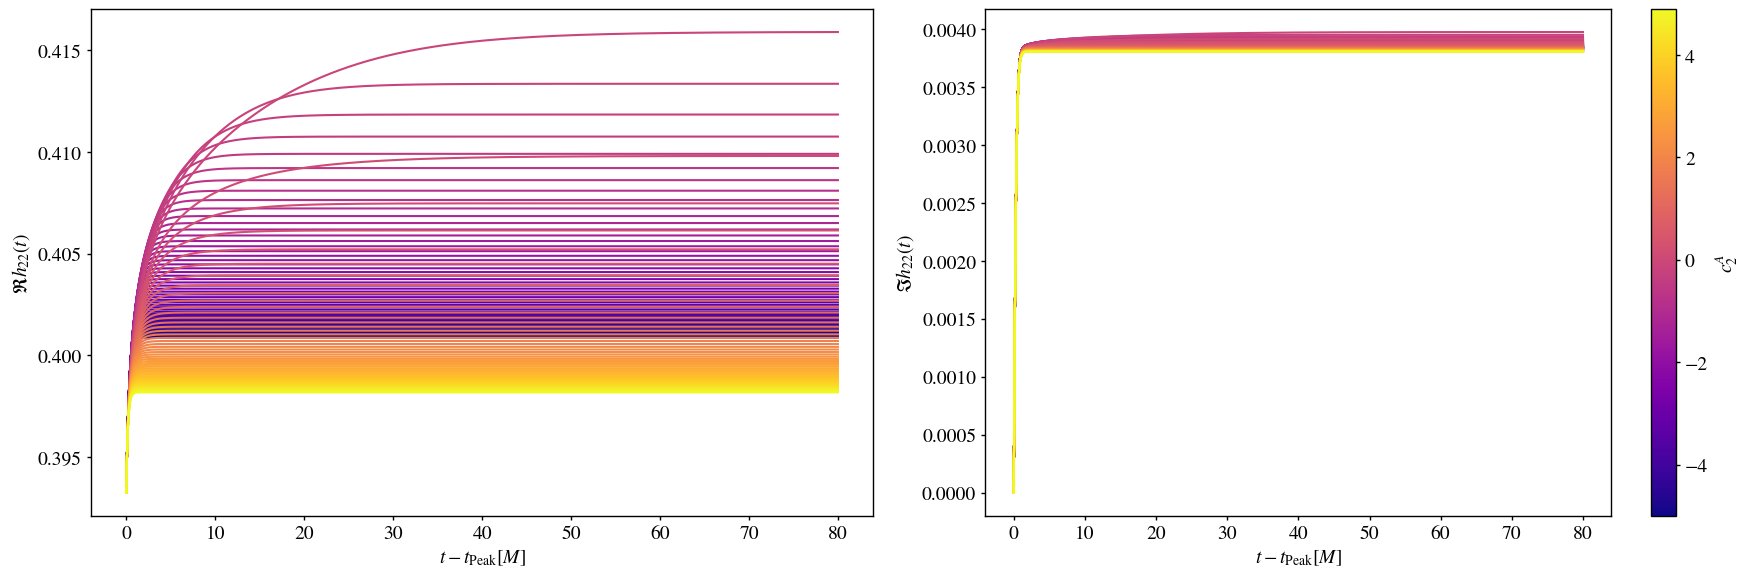

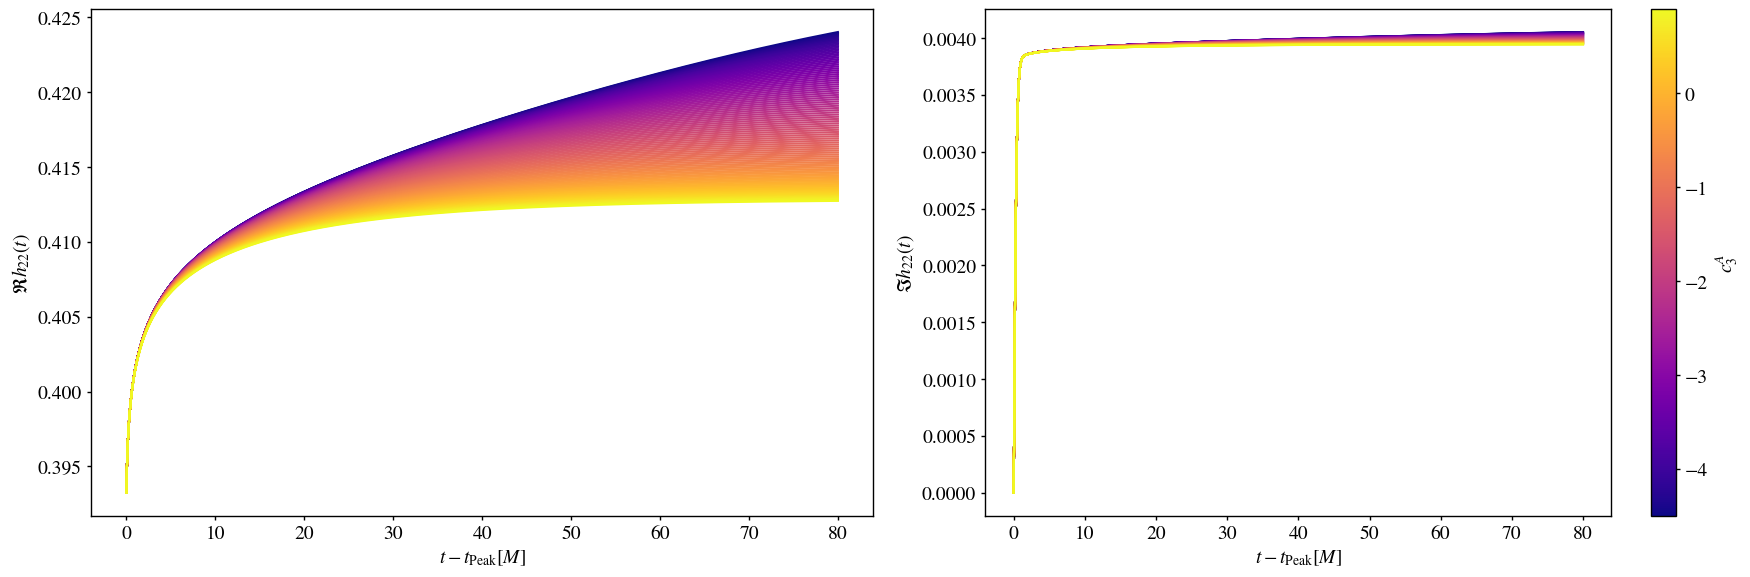

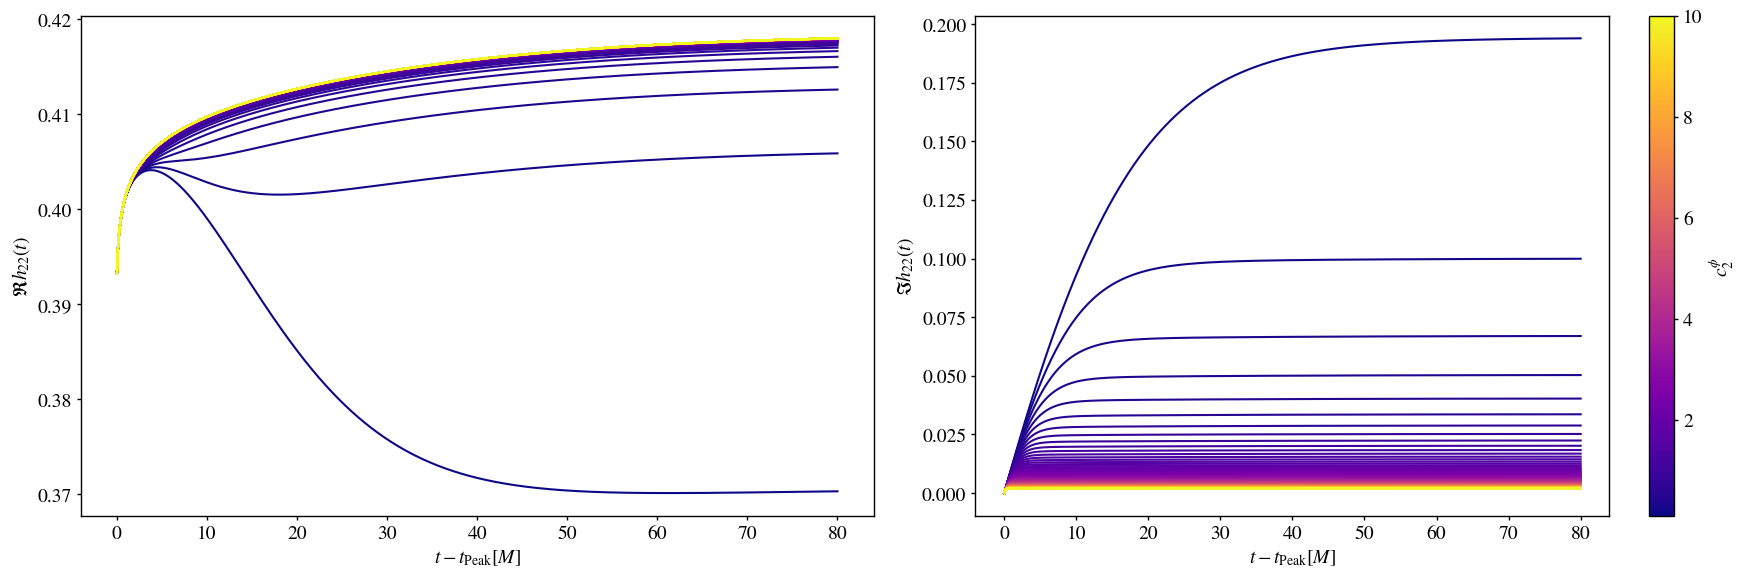

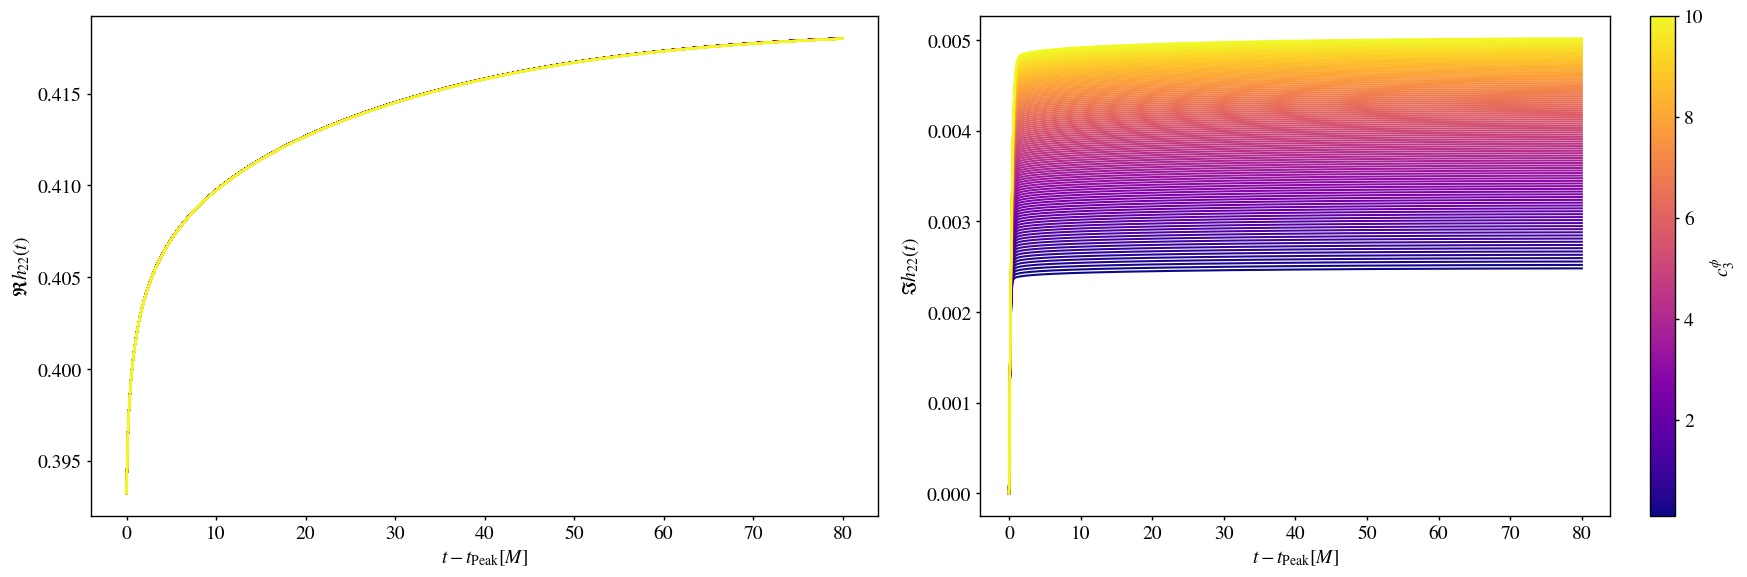

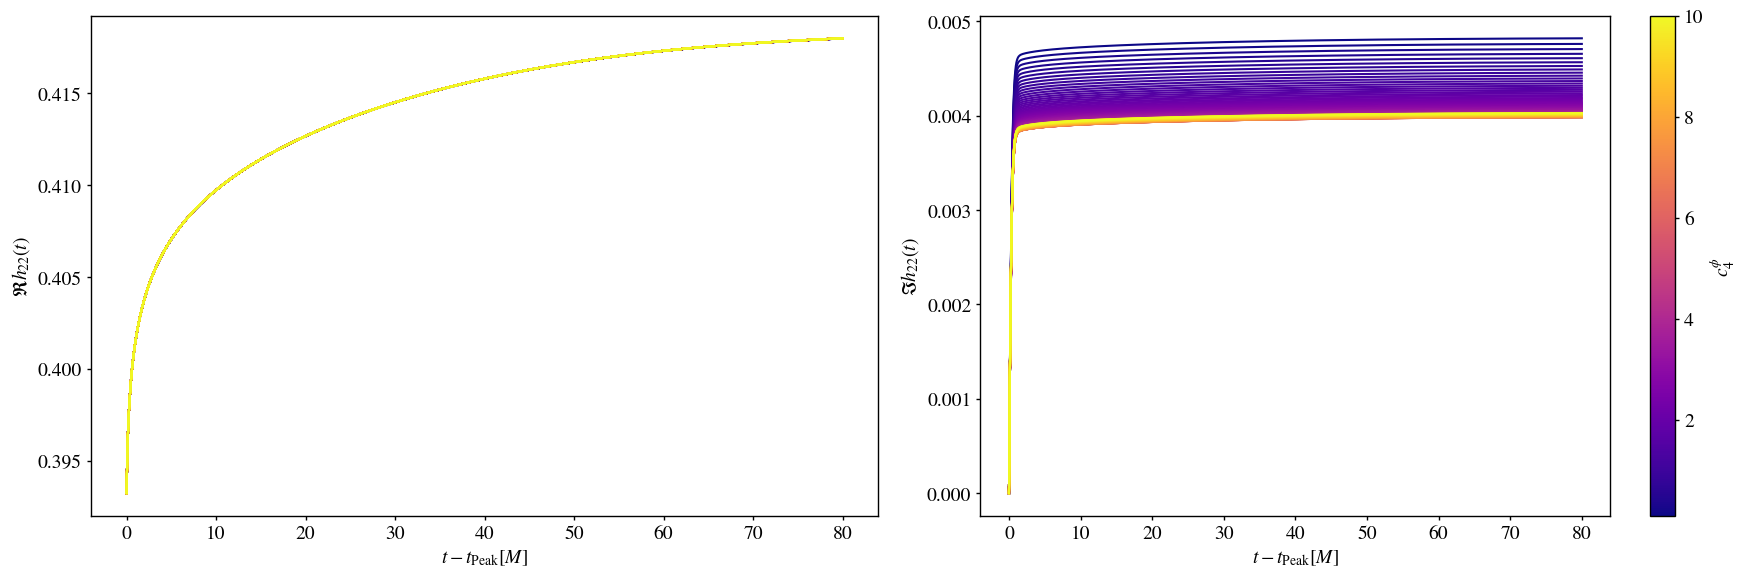

In [25]:
plot_all_variations(c2Amin, c2Amax, c3Amin, c3Amax, c2Pmin, c2Pmax, c3Pmin, c3Pmax, c4Pmin, c4Pmax)